# 🚗 Electric Vehicle Sales Analysis & Forecasting in India
# 📌 Problem Statement

With the rapid adoption of Electric Vehicles (EVs) in India, businesses and policymakers need data-driven insights to understand sales patterns, regional demand, and future growth trends.

This project aims to analyze historical EV sales data across different regions, product categories, and customer segments to:

- Identify key drivers of EV adoption

- Analyze sales performance across time and geography

- Understand customer purchasing behavior

- Forecast future EV sales trends

The insights generated will help:

- Businesses optimize inventory and pricing strategies

- Companies identify high-growth regions and segments

- Policymakers evaluate the impact of EV adoption initiatives

# 🎯 Objectives

1. Perform exploratory data analysis (EDA) to uncover trends and patterns

2. Build an interactive dashboard for business stakeholders

3. Analyze time-based trends in EV sales

4. Develop a time series forecasting model to predict future sales

5. Generate actionable insights for decision-making

In [3]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings("ignore")

# 📊 Dataset Column Description – EV Sales Data

## 🧾 Overview

This dataset represents electric vehicle (EV) sales transactions across various regions in India. Each row corresponds to a single sales transaction.

---

## 📌 Column Details

### 1. **Order_ID**

* Unique identifier for each sales transaction
* Format: `EV00001`, `EV00002`, etc.
* Used for tracking and referencing individual orders

---

### 2. **Order_Date**

* Date on which the vehicle purchase was made
* Format: `YYYY-MM-DD`
* Used for time series analysis, trend analysis, and forecasting

---

### 3. **Region**

* Broad geographical classification of the sale
* Values: North, South, East, West
* Helps analyze regional adoption patterns of EVs

---

### 4. **City**

* City where the transaction took place
* Represents urban demand centers
* Useful for identifying top-performing cities

---

### 5. **Product_Category**

* Type of electric vehicle sold
* Categories include:

  * 2-Wheeler EV
  * 4-Wheeler EV
  * Commercial EV
* Helps segment analysis by vehicle type

---

### 6. **Product_Name**

* Specific EV model sold
* Examples:

  * Ola S1
  * Ather 450X
  * Tata Nexon EV
* Enables product-level performance analysis

---

### 7. **Sales**

* Total transaction value (in INR ₹)
* Calculated as:
  **Sales = Price × Quantity**
* Key metric for revenue analysis

---

### 8. **Quantity**

* Number of units sold in a single transaction
* Helps in volume analysis and demand estimation

---

### 9. **Profit**

* Profit earned from the transaction (in INR ₹)
* Used to evaluate business performance

---

### 10. **Customer_Segment**

* Type of customer making the purchase
* Categories:

  * Individual
  * Corporate
  * Fleet
* Helps understand buying behavior

---

### 11. **Payment_Mode**

* Method used to complete the transaction
* Options include:

  * UPI
  * Loan
  * Lease
  * Cash
* Useful for financial and behavioral insights

---

## 🎯 Key Notes

* The dataset is structured for both **dashboarding** and **time series forecasting**
* Suitable for analyzing **growth trends, customer behavior, and regional adoption patterns**

---


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# load the dataset
ev_df = pd.read_excel(r'/content/drive/MyDrive/ev_sales.xlsx')
ev_df.head(5)

,Order_ID,Order_Date,Region,City,Product_Category,Product_Name,Sales,Quantity,Profit,Customer_Segment,Payment_Mode
0,EV00001,2022-11-23,West,Ahmedabad,2-Wheeler EV,TVS iQube,581026.61,3,87615.35,Fleet,Loan
1,EV00002,2024-06-08,East,Patna,Commercial EV,Electric Truck,5468513.79,3,465069.86,Corporate,Loan
2,EV00003,2025-10-20,West,Mumbai,2-Wheeler EV,Ather 450X,2305775.12,3,323615.92,Individual,UPI
3,EV00004,2023-04-07,North,Lucknow,4-Wheeler EV,Mahindra XUV400,9180495.64,3,1303341.03,Individual,Lease
4,EV00005,2022-02-20,North,Chandigarh,Commercial EV,Electric Auto,2796740.97,3,406448.32,Individual,Cash


In [7]:
print(f"Shape of the data : {ev_df.shape}", end="\n\n")
print(f"No. of missing values in the data : \n{ev_df.isnull().sum()}", end="\n\n")
print(f"No. of duplicates values in the data : {ev_df.duplicated().sum()}")

Shape of the data : (1200, 11)

No. of missing values in the data : 
Order_ID            0
Order_Date          0
Region              0
City                0
Product_Category    0
Product_Name        0
Sales               0
Quantity            0
Profit              0
Customer_Segment    0
Payment_Mode        0
dtype: int64

No. of duplicates values in the data : 0


In [8]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1200 non-null   object 
 1   Order_Date        1200 non-null   object 
 2   Region            1200 non-null   object 
 3   City              1200 non-null   object 
 4   Product_Category  1200 non-null   object 
 5   Product_Name      1200 non-null   object 
 6   Sales             1200 non-null   float64
 7   Quantity          1200 non-null   int64  
 8   Profit            1200 non-null   float64
 9   Customer_Segment  1200 non-null   object 
 10  Payment_Mode      1200 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 103.3+ KB


In [9]:
# the Order_Date is of object datatype and is not in sequential order, so first convert into datetime then sort it
ev_df['Order_Date'] = pd.to_datetime(ev_df['Order_Date'])
ev_df = ev_df.sort_values(by='Order_Date')

# remove the Order_ID column
ev_df.drop(columns=['Order_ID'], inplace=True)
ev_df.head(5)

,Order_Date,Region,City,Product_Category,Product_Name,Sales,Quantity,Profit,Customer_Segment,Payment_Mode
494,2022-01-01,North,Lucknow,2-Wheeler EV,Ola S1,529313.66,5,63216.51,Individual,Cash
1126,2022-01-02,North,Delhi,4-Wheeler EV,MG ZS EV,6319498.01,4,644453.76,Corporate,Lease
626,2022-01-03,West,Pune,2-Wheeler EV,Ola S1,847858.70,5,134120.14,Corporate,Lease
660,2022-01-03,West,Ahmedabad,2-Wheeler EV,Ather 450X,480574.74,3,83880.68,Fleet,Lease
835,2022-01-04,West,Ahmedabad,4-Wheeler EV,MG ZS EV,6104807.84,3,801104.87,Individual,Loan


In [10]:
# extract important time features
ev_df['Year'] = ev_df["Order_Date"].dt.year
ev_df['Month'] = ev_df["Order_Date"].dt.month
ev_df['Quarter'] = ev_df["Order_Date"].dt.quarter

ev_df.head(5)

,Order_Date,Region,City,Product_Category,Product_Name,Sales,Quantity,Profit,Customer_Segment,Payment_Mode,Year,Month,Quarter
494,2022-01-01,North,Lucknow,2-Wheeler EV,Ola S1,529313.66,5,63216.51,Individual,Cash,2022,1,1
1126,2022-01-02,North,Delhi,4-Wheeler EV,MG ZS EV,6319498.01,4,644453.76,Corporate,Lease,2022,1,1
626,2022-01-03,West,Pune,2-Wheeler EV,Ola S1,847858.70,5,134120.14,Corporate,Lease,2022,1,1
660,2022-01-03,West,Ahmedabad,2-Wheeler EV,Ather 450X,480574.74,3,83880.68,Fleet,Lease,2022,1,1
835,2022-01-04,West,Ahmedabad,4-Wheeler EV,MG ZS EV,6104807.84,3,801104.87,Individual,Loan,2022,1,1


For creating dashboard we will use Power BI, so export the data

In [11]:
# export ev_df for creating dashboard and create a dataset for doing time series analysis and forecasting future sales
ev_sales = ev_df[['Order_Date', 'Sales', 'Quantity', 'Year', 'Month', 'Quarter']].copy()
ev_df.to_csv('ev_sales', index=False)

## **Univariate Analysis**

In [12]:
def univariate_num(col):
    print(f"Summary Statistic: \n{ev_df[col].describe()}")
    print(f"Skewness: {ev_df[col].skew()}")

    # create 2 subplots
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # plot the histogram
    sns.histplot(ev_df, x=col, kde=True, ax=ax[0])

    # plot the box plot
    sns.boxplot(ev_df, y=col, ax=ax[1])

    # set the title of the figure
    fig.suptitle(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

    print("="*100)
    print("="*100)

In [13]:
num_cols = ['Sales', 'Quantity']
print(num_cols)

['Sales', 'Quantity']


Summary Statistic: 
count    1.200000e+03
mean     7.119741e+06
std      8.648027e+06
min      9.328788e+04
25%      1.279636e+06
50%      3.562920e+06
75%      9.105841e+06
max      5.950263e+07
Name: Sales, dtype: float64
Skewness: 2.0404736900538114


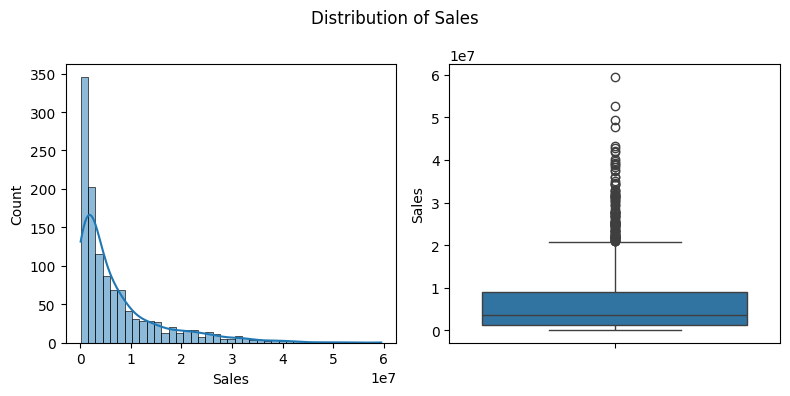

Summary Statistic: 
count    1200.000000
mean        3.037500
std         1.409284
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64
Skewness: -0.0396856502541409


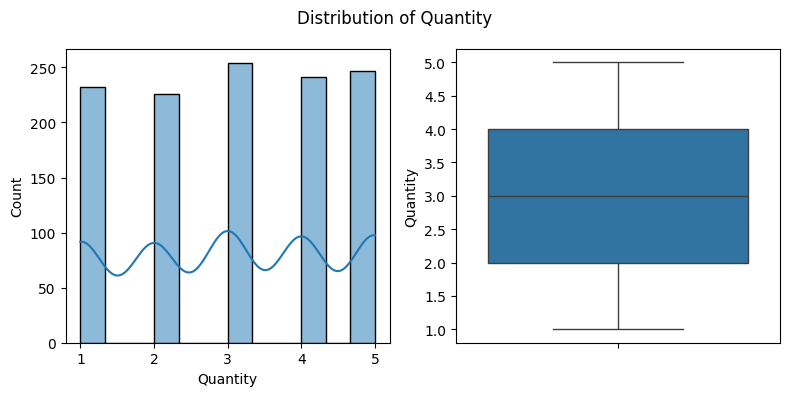

In [14]:
for col in num_cols:
    univariate_num(col)

### **Insights**
1. The distribution of **Sales** and **Profit** column is right skewed with lots of outliers.
2. The **Quantity** distribution is fairly balanced, with a mode around 3 units, indicating that customers typically purchase around three vehicles per transaction.

## **Time Series Analysis**

In [15]:
ev_sales1 = ev_sales.set_index('Order_Date').resample('D')[['Sales', 'Quantity']].sum()
ev_sales1.head(5)

,Sales,Quantity
Order_Date,,
2022-01-01,529313.66,5
2022-01-02,6319498.01,4
2022-01-03,1328433.44,8
2022-01-04,6595506.79,6
2022-01-05,458392.65,4


In [16]:
import plotly.express as px
import plotly.graph_objects as go

In [17]:
# plot the daily sales over time
fig1 = px.line(
    ev_sales1,
    y='Sales',
    markers='o',
    title='Sales Trend over time'
)

fig2 = px.line(
    ev_sales1,
    y='Quantity',
    markers='o',
    title='Demands Trend over time'
)

fig1.show()
fig2.show()

In [18]:
# plot the monthly sales data over time
monthly_data = ev_sales1.resample('M')[['Sales', 'Quantity']].sum()

fig1 = px.line(
    monthly_data,
    y='Sales',
    markers='o',
    title='Monthly Sales Trend'
)

fig2 = px.line(
    monthly_data,
    y='Quantity',
    markers='o',
    title='Monthly Demands Trend'
)

fig1.show()
fig2.show()

## **Time Series Decomposition**

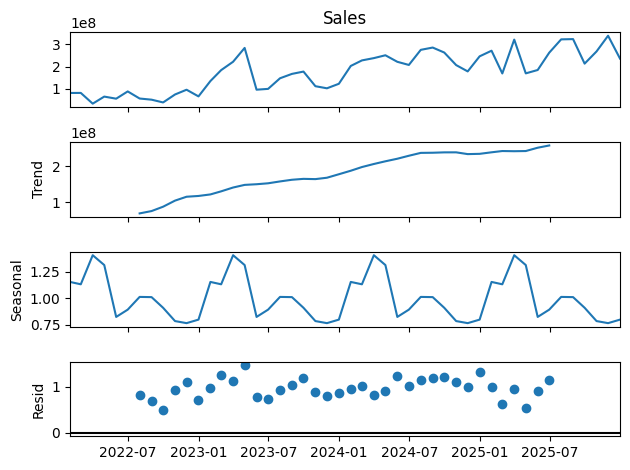

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

sales_decompose = seasonal_decompose(
    x=monthly_data['Sales'],
    model='multiplicative',
    period=12
)

sales_decompose.plot()
plt.show()

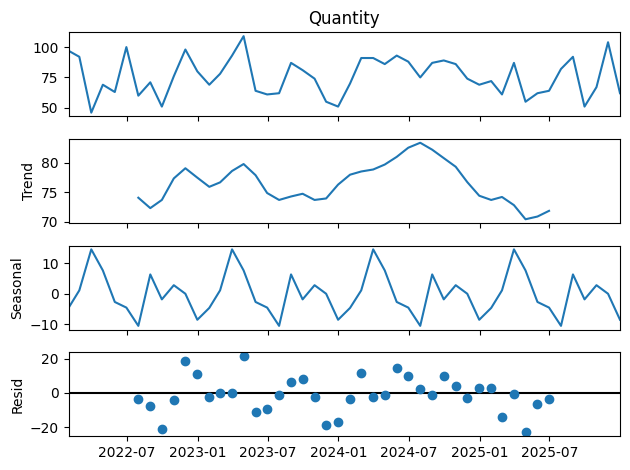

In [20]:
quantity_decompose = seasonal_decompose(
    x=monthly_data['Quantity'],
    model='additive',
    period=12
)

quantity_decompose.plot()
plt.show()

In [21]:
# extract important time features like month, year
monthly_data['Year'] = monthly_data.index.year
monthly_data['Month'] = monthly_data.index.month
monthly_data['Quarter'] = monthly_data.index.quarter
monthly_data['Day of Week'] = monthly_data.index.dayofweek
monthly_data.head(5)

,Sales,Quantity,Year,Month,Quarter,Day of Week
Order_Date,,,,,,
2022-01-31,81730493.28,97,2022,1,1,0
2022-02-28,81930329.51,92,2022,2,1,0
2022-03-31,33624876.35,46,2022,3,1,3
2022-04-30,65388983.14,69,2022,4,2,5
2022-05-31,55961740.53,63,2022,5,2,1


## **Plotting Features over Time (Month)**

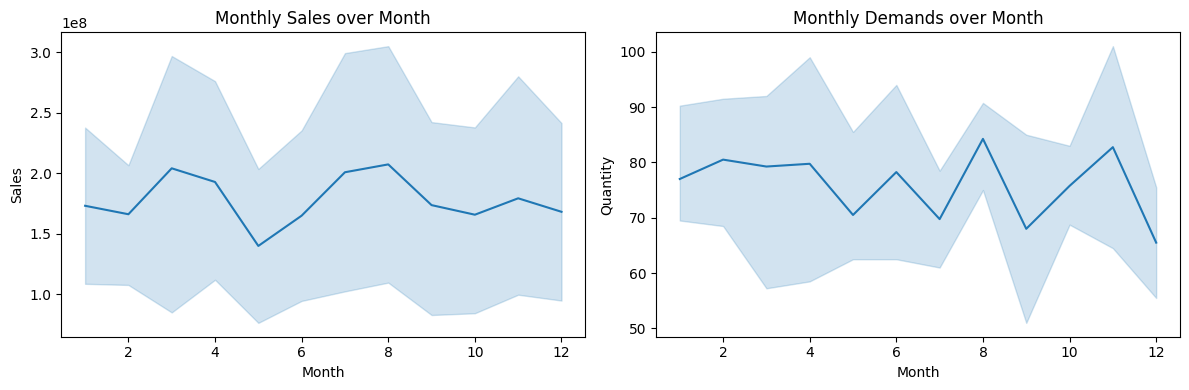

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(monthly_data, x='Month', y='Sales', ax=ax[0])
ax[0].set_title('Monthly Sales over Month')

sns.lineplot(monthly_data, x='Month', y='Quantity', ax=ax[1])
ax[1].set_title('Monthly Demands over Month')

plt.tight_layout()
plt.show()

## **Plotting Sales over Year by Month**

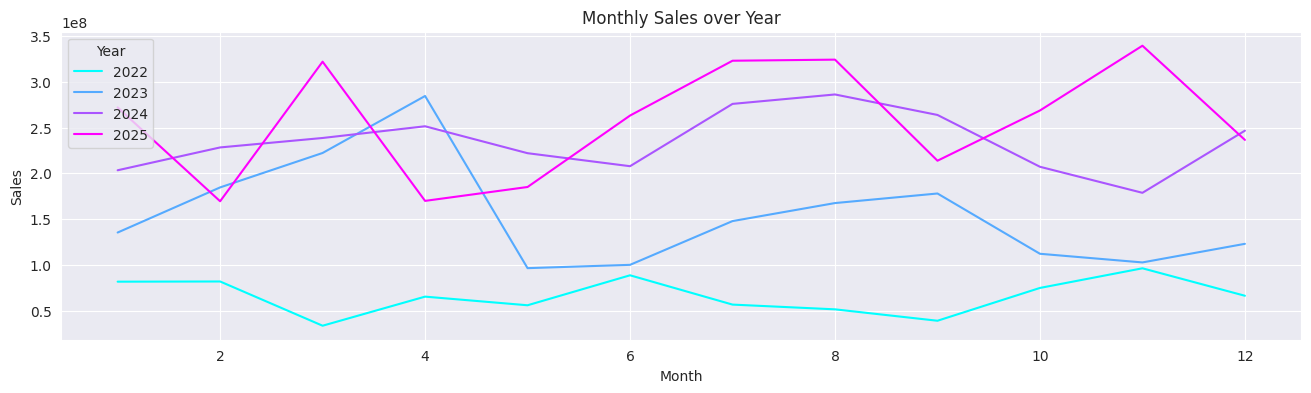

In [23]:
plt.figure(figsize=(16, 4))

sns.set_style('darkgrid')

plt.title('Monthly Sales over Year')
sns.lineplot(monthly_data, x='Month', y='Sales', hue='Year', palette='cool', ci=None)

plt.show()

## **Correlation Plot**

<Axes: >

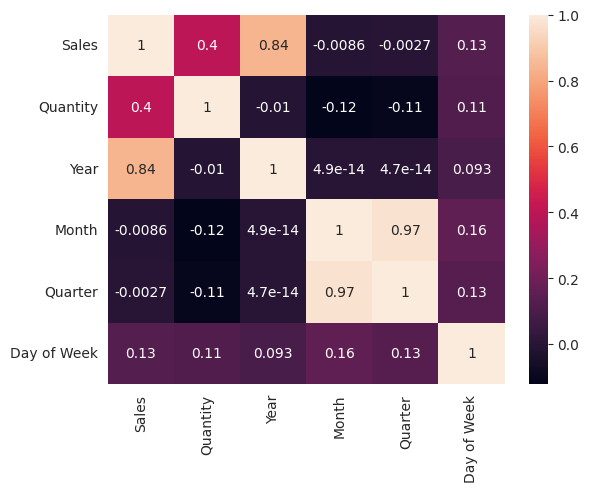

In [24]:
sns.heatmap(monthly_data.corr(), annot=True)

## **Box Plots**

### Yearly Distribution of Sales

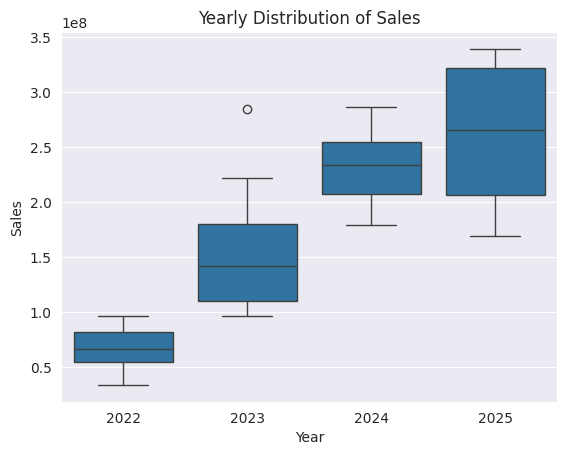

In [25]:
plt.title('Yearly Distribution of Sales')
sns.boxplot(monthly_data, x='Year', y='Sales')
plt.show()

## **Stationarity Test**

In [26]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(data):
    result = adfuller(data)
    print("Results of ADF Test")
    print('='*20)

    if result[1] < 0.05:
        print(f"P-value: {result[1]}\nData is stationary")
    else:
        print(f"P-value: {result[1]}\nData is not stationary")

check_stationarity(monthly_data['Sales'])

Results of ADF Test
P-value: 0.08152202618742777
Data is not stationary


## **Transforming Sales into Stationary by Difference Method**

In [27]:
# making Sales data stationary
# 1. Differencing

# check the stationarity of the data before differencing
print(f"{"-"*10}Checking Stationarity Before Differencing{"-"*10}")
check_stationarity(monthly_data['Sales'])

# apply differencing method
monthly_data['Sales_Diff'] = monthly_data['Sales'].diff().fillna(0)

# check the stationarity of the data after differencing
print()
print(f"{"-"*10}Checking Stationarity After Differencing{"-"*10}")
check_stationarity(monthly_data['Sales_Diff'])

----------Checking Stationarity Before Differencing----------
Results of ADF Test
P-value: 0.08152202618742777
Data is not stationary

----------Checking Stationarity After Differencing----------
Results of ADF Test
P-value: 4.676986983249364e-07
Data is stationary


## **ACF, PACF Plots**

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

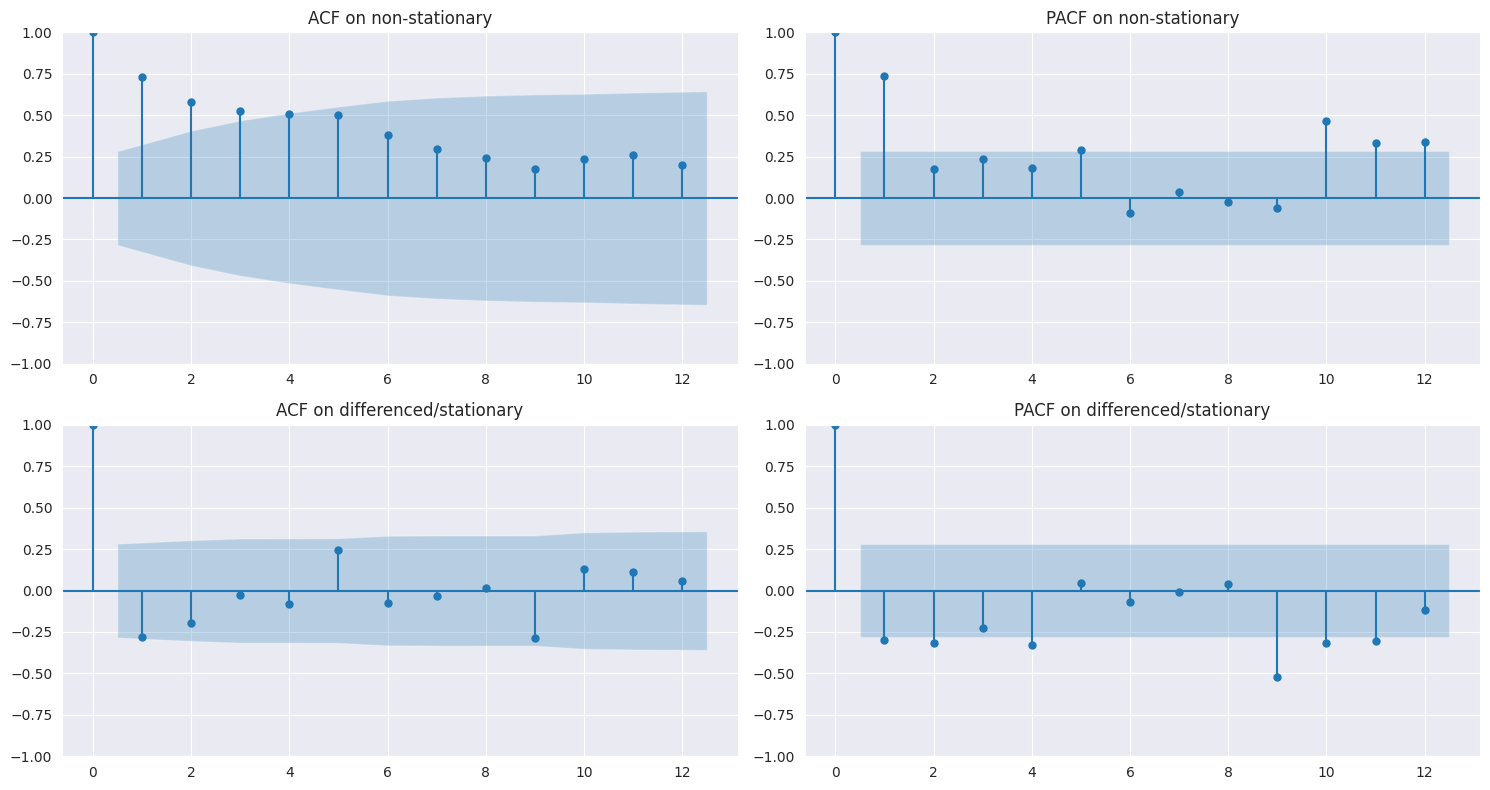

In [29]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

plot_acf(monthly_data['Sales'], lags=12, ax=ax[0, 0], title='ACF on non-stationary')
plot_pacf(monthly_data['Sales'], lags=12, ax=ax[0, 1], method='ols', title='PACF on non-stationary')

plot_acf(monthly_data['Sales_Diff'], lags=12, ax=ax[1, 0], title='ACF on differenced/stationary')
plot_pacf(monthly_data['Sales_Diff'], lags=12, ax=ax[1, 1], method='ols', title='PACF on differenced/stationary')

plt.tight_layout()
plt.show()

In [30]:
# split the data into training and testing sets
train_size = int(len(monthly_data) * 0.8)
train, test = monthly_data.iloc[:train_size], monthly_data.iloc[train_size:]

In [31]:
display(f'Train shape: {train.shape}')
display(train.head())

display(f'Test shape: {test.shape}')
test.head()

'Train shape: (38, 7)'

,Sales,Quantity,Year,Month,Quarter,Day of Week,Sales_Diff
Order_Date,,,,,,,
2022-01-31,81730493.28,97,2022,1,1,0,0.00
2022-02-28,81930329.51,92,2022,2,1,0,199836.23
2022-03-31,33624876.35,46,2022,3,1,3,-48305453.16
2022-04-30,65388983.14,69,2022,4,2,5,31764106.79
2022-05-31,55961740.53,63,2022,5,2,1,-9427242.61


'Test shape: (10, 7)'

,Sales,Quantity,Year,Month,Quarter,Day of Week,Sales_Diff
Order_Date,,,,,,,
2025-03-31,3.219233e+08,87,2025,3,1,0,1.523914e+08
2025-04-30,1.699400e+08,55,2025,4,2,2,-1.519833e+08
2025-05-31,1.851034e+08,62,2025,5,2,5,1.516346e+07
2025-06-30,2.631023e+08,64,2025,6,2,0,7.799887e+07
2025-07-31,3.229727e+08,82,2025,7,3,3,5.987041e+07


Test RMSE: 84886278.679


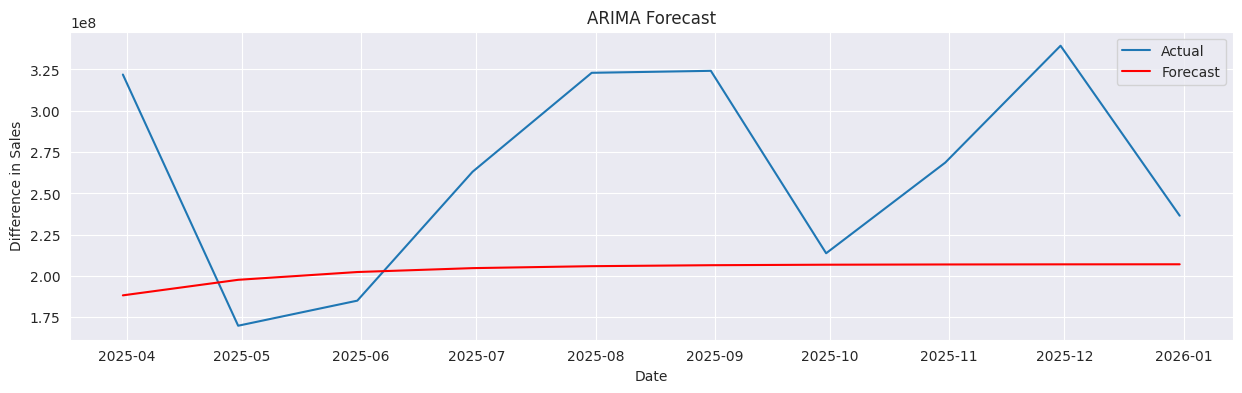

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# fit the model
arima = ARIMA(train['Sales'], order=(1, 1, 1))
arima_model = arima.fit()

# make predictions from model
pred = arima_model.forecast(steps=len(test))

# calculate the error
error = root_mean_squared_error(test['Sales'], pred)
print('Test RMSE: %.3f' % error)

# plot the results
plt.figure(figsize=(15, 4))
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, pred, color='red', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Difference in Sales')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()


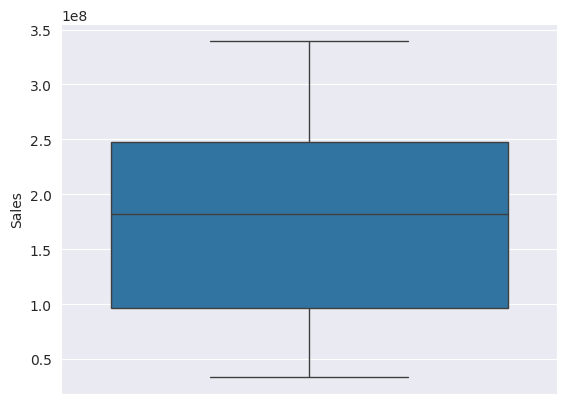

In [33]:
sns.boxplot(monthly_data, y='Sales')
plt.show()

In [34]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
minmax_scaler = MinMaxScaler()
train[['Sales']] = minmax_scaler.fit_transform(train[['Sales']])
test[['Sales']] = minmax_scaler.transform(test[['Sales']])

In [62]:
# create a dataset
def create_dataset(data, timestep=1):
  X, y = [], []
  for i in range(len(data)-timestep):
    X.append(data[i:(i+timestep)])
    y.append(data.iloc[i+timestep].values)
  return np.array(X), np.array(y)

X_train, y_train = create_dataset(train[['Sales']])
X_test, y_test = create_dataset(test[['Sales']])

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [64]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(100, activation='tanh', input_shape=(3, X_train.shape[2])))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer='adam', loss='mse')

In [65]:
# define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# train the model with early stopping
history = rnn_model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), batch_size=1, callbacks=[early_stopping])

# Evaluate the model
loss = rnn_model.evaluate(X_test, y_test)
print(f'Validation Loss: {loss}')

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1388 - val_loss: 0.0881
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0503 - val_loss: 0.0823
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0446 - val_loss: 0.0936
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0425 - val_loss: 0.0913
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0396 - val_loss: 0.0855
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0417 - val_loss: 0.0956
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0399 - val_loss: 0.0884
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0389 - val_loss: 0.0856
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0381 - val_loss: 0.0938
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0383 - val_loss: 0.0866
Epoch 11/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0391 - val_loss: 0.0891
Epoch 12/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0404 - val_l

In [66]:
# make predictions
rnn_pred = rnn_model.predict(X_test)
rnn_pred = minmax_scaler.inverse_transform(rnn_pred)  # Inverse transform to original scale

# inverse transform the true values for comparison
y_test = y_test.reshape(-1, 1)
y_test = minmax_scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


In [67]:
rmse = root_mean_squared_error(y_test, rnn_pred)
r2 = r2_score(y_test, rnn_pred)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

RMSE: 72462074.09709212
R2 Score: -0.532158603161605


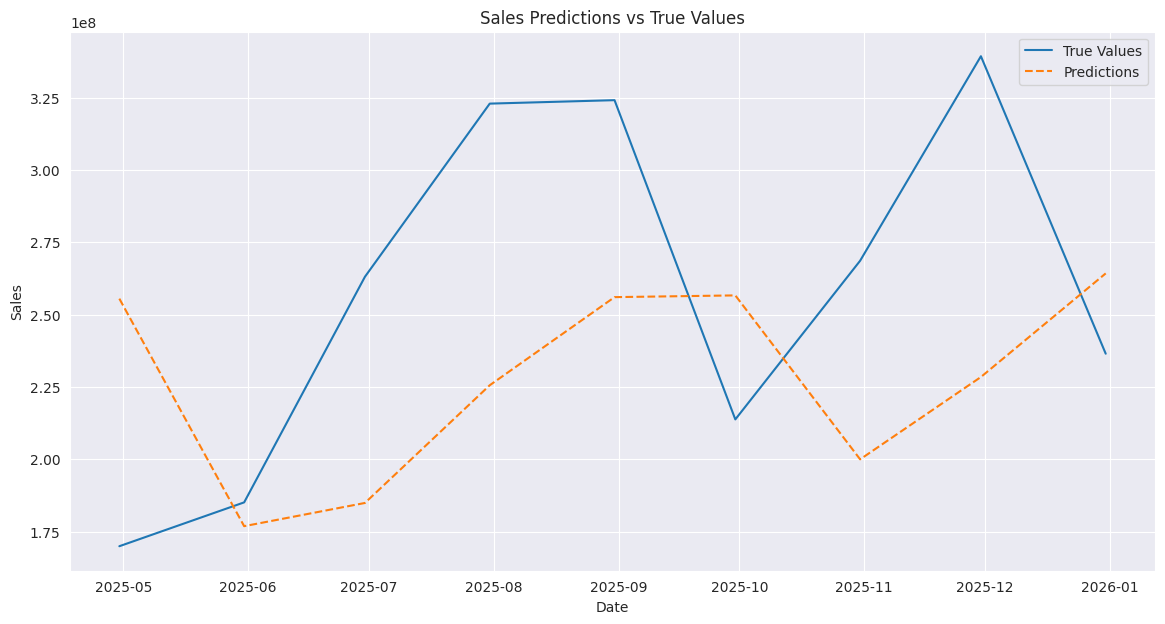

In [68]:
# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(monthly_data.index[-len(y_test):], y_test, label='True Values')
plt.plot(monthly_data.index[-len(y_test):], rnn_pred, label='Predictions', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Predictions vs True Values')
plt.legend()
plt.show()